<a href="https://colab.research.google.com/github/brightliam20-ops/AVCAD-ASSIGNMENT/blob/main/Assignment_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# prompt: General introduction for the notebook.
## Statistical Analyses: PCA, PCoA, and LDA

This notebook will guide you through performing Principal Component Analysis (PCA), Principal Coordinate Analysis (PCoA), and Linear Discriminant Analysis (LDA) on environmental variables, using 'Catchment_name' as a grouping factor for visualization.

# prompt: Set up the environment and prepare for data loading. This markdown cell also provides instructions to the user to replace placeholder data.
### 1. Setup and Data Loading

First, we'll install and import the necessary libraries. Since no data was provided, a synthetic dataset will be generated as a placeholder. **Please replace the data generation code with your actual data loading from a CSV or other source.** Ensure your data contains quantitative environmental variables and a 'Catchment_name' column.

In [1]:
# prompt: Implicitly required for PCA, PCoA, and LDA analyses.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import MDS # For PCoA (via MDS for Euclidean distance)

# For installing missing libraries like scikit-bio for PCoA on non-Euclidean distances if needed
# !pip install scikit-bio

In [2]:
# prompt: 'using sites from the Douro, Tejo, Mondego and Minho basins' and 'quantitative environmental variables'.
# Note: Generated placeholder data since no actual data was provided by the user. Instructions are included for the user to replace this.

# --- Placeholder Data Generation ---
# Replace this section with your actual data loading code.

# Create a dummy dataset with environmental variables and 'Catchment_name'
np.random.seed(42)
num_sites = 100

environmental_vars = pd.DataFrame({
    'pH': np.random.normal(7, 0.5, num_sites),
    'Temperature': np.random.normal(15, 2, num_sites),
    'DO': np.random.normal(8, 1, num_sites),
    'Conductivity': np.random.normal(200, 50, num_sites),
    'Turbidity': np.random.normal(10, 3, num_sites),
    'Nitrates': np.random.normal(5, 1, num_sites)
})

# Assign catchment names, ensuring some variation
catchment_names = ['Douro', 'Tejo', 'Mondego', 'Minho']
catchment_labels = np.random.choice(catchment_names, num_sites, p=[0.25, 0.25, 0.25, 0.25])

df = environmental_vars
df['Catchment_name'] = catchment_labels

# Introduce some differences based on catchment for better separation in analysis
for i, name in enumerate(catchment_names):
    idx = df['Catchment_name'] == name
    df.loc[idx, 'pH'] = df.loc[idx, 'pH'] + (i - 1.5) * 0.2 # Shift pH slightly
    df.loc[idx, 'Temperature'] = df.loc[idx, 'Temperature'] + (i - 1.5) * 0.5 # Shift Temperature

display(df.head())
display(df['Catchment_name'].value_counts())

# Separate features (environmental variables) and target (catchment names)
X = df.drop('Catchment_name', axis=1)
y = df['Catchment_name']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

display(X_scaled_df.head())

,pH,Temperature,DO,Conductivity,Turbidity,Nitrates,Catchment_name
0,6.948357,11.419259,8.357787,158.550249,5.216717,5.926178,Douro
1,7.030868,14.408709,8.560785,171.990948,8.201875,6.909417,Mondego
2,7.423844,14.564571,9.083051,237.364680,10.015731,3.601432,Mondego
3,7.861515,13.645445,9.053802,230.518513,10.140942,5.562969,Mondego
4,6.982923,14.927429,6.622331,198.954920,8.649804,4.349357,Mondego


,count
Catchment_name,
Mondego,29
Douro,26
Tejo,25
Minho,20


,pH,Temperature,DO,Conductivity,Turbidity,Nitrates
0,0.028758,-1.866553,0.271485,-1.063848,-1.453539,1.133392
1,0.194922,-0.312396,0.459646,-0.758263,-0.513389,2.203400
2,0.986316,-0.231367,0.943743,0.728061,0.057869,-1.396507
3,1.867718,-0.709202,0.916631,0.572408,0.097303,0.738131
4,0.098369,-0.042724,-1.337135,-0.145216,-0.372318,-0.582579


# prompt: Introduce the PCA section.
### 2. Principal Component Analysis (PCA)

PCA is used to reduce the dimensionality of your dataset while retaining as much variance as possible. We will perform PCA and visualize the first two principal components as a biplot, coloring points by 'Catchment_name'.

Explained variance by PC1: 0.25
Explained variance by PC2: 0.21
Total explained variance by PC1 and PC2: 0.46


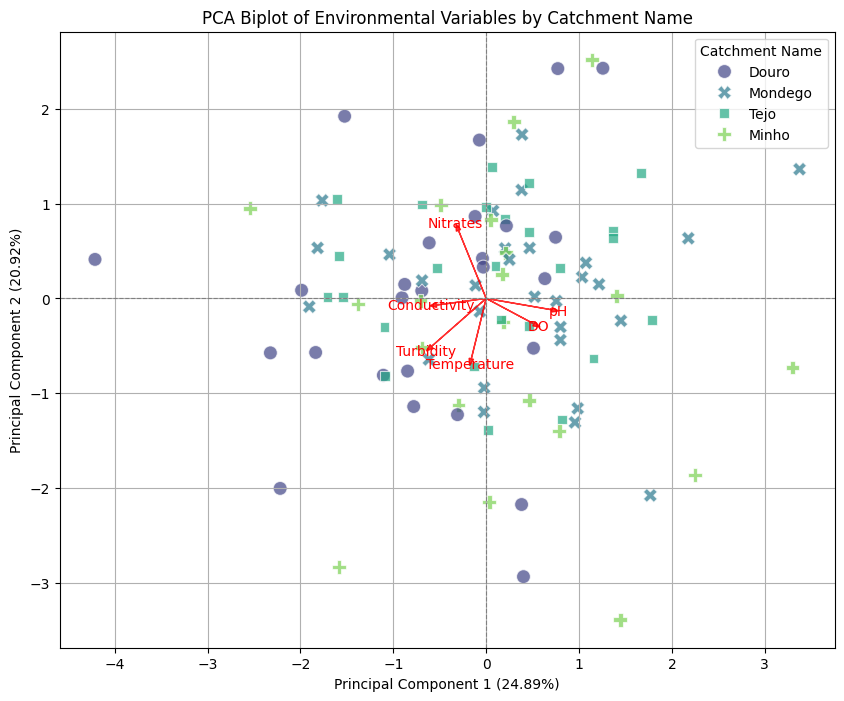

In [3]:
# prompt: 'Run a PCA based on quantitative environmental variables' and 'Produce a biplot with ‘Catchment_name’ as a grouping variable.'
# Perform PCA
pca = PCA(n_components=2) # Retain 2 principal components for 2D visualization
pc_components = pca.fit_transform(X_scaled)
pc_df = pd.DataFrame(data=pc_components, columns=['PC1', 'PC2'])
pc_df['Catchment_name'] = y.reset_index(drop=True)

# Explainable variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
print(f"Explained variance by PC1: {explained_variance_ratio[0]:.2f}")
print(f"Explained variance by PC2: {explained_variance_ratio[1]:.2f}")
print(f"Total explained variance by PC1 and PC2: {explained_variance_ratio.sum():.2f}")

# Plotting the PCA Biplot
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1', y='PC2', hue='Catchment_name', data=pc_df,
    s=100, alpha=0.7, palette='viridis', style='Catchment_name'
)

# Add loadings for interpretation (biplot)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
for i, var in enumerate(X.columns):
    plt.arrow(0, 0, loadings[i, 0], loadings[i, 1], color='r', alpha=0.8, head_width=0.05)
    plt.text(loadings[i, 0] * 1.1, loadings[i, 1] * 1.1, var, color='r', ha='center', va='center')

plt.title('PCA Biplot of Environmental Variables by Catchment Name')
plt.xlabel(f'Principal Component 1 ({explained_variance_ratio[0]*100:.2f}%)')
plt.ylabel(f'Principal Component 2 ({explained_variance_ratio[1]*100:.2f}%)')
plt.grid(True)
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.legend(title='Catchment Name')
plt.show()

# prompt: Introduce the PCoA section.
### 3. Principal Coordinate Analysis (PCoA)

PCoA (also known as Multidimensional Scaling - MDS when using Euclidean distances) is used to visualize the similarity or dissimilarity between objects based on a distance matrix. We'll use Euclidean distance here and project the sites onto the first two axes, grouped by 'Catchment_name'.

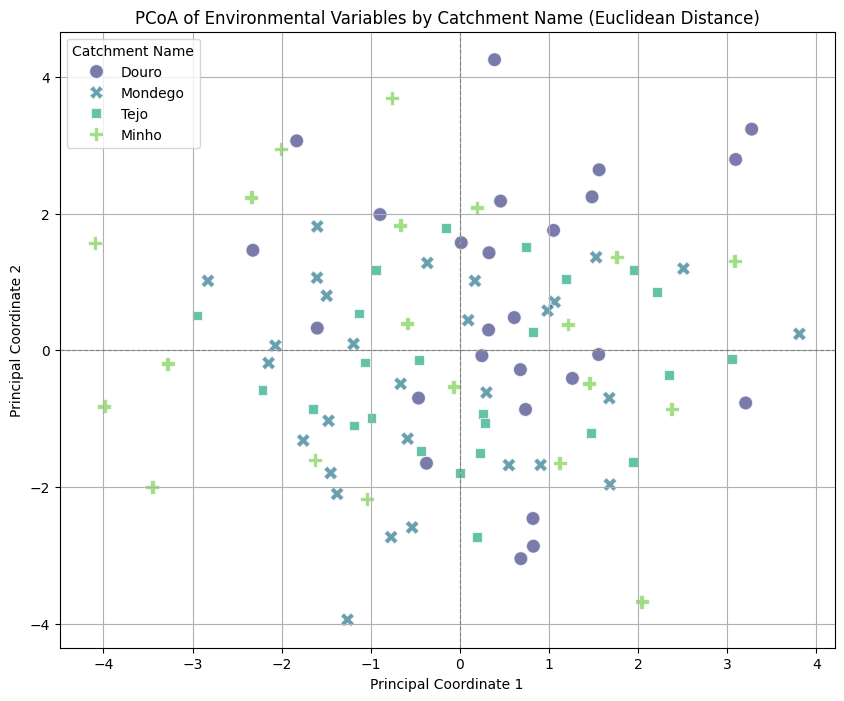

In [4]:
# prompt: 'run a PCoA and project the sites using the resulting first two axis. Use also the ‘Catchment_name’ as a grouping variable.'
# Perform PCoA using MDS with Euclidean distance
# For non-Euclidean distances, libraries like scikit-bio might be needed with `skbio.stats.ordination.pcoa`
mds = MDS(n_components=2, dissimilarity='euclidean', random_state=42)
pcoa_components = mds.fit_transform(X_scaled)
pcoa_df = pd.DataFrame(data=pcoa_components, columns=['PCoA1', 'PCoA2'])
pcoa_df['Catchment_name'] = y.reset_index(drop=True)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PCoA1', y='PCoA2', hue='Catchment_name', data=pcoa_df,
    s=100, alpha=0.7, palette='viridis', style='Catchment_name'
)
plt.title('PCoA of Environmental Variables by Catchment Name (Euclidean Distance)')
plt.xlabel('Principal Coordinate 1')
plt.ylabel('Principal Coordinate 2')
plt.grid(True)
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.legend(title='Catchment Name')
plt.show()

# prompt: Introduce the LDA section.
### 4. Linear Discriminant Analysis (LDA)

LDA is a supervised dimensionality reduction technique that aims to find a linear combination of features that characterizes or separates two or more classes of objects or events. We will use 'Catchment_name' as the pre-determined groups.

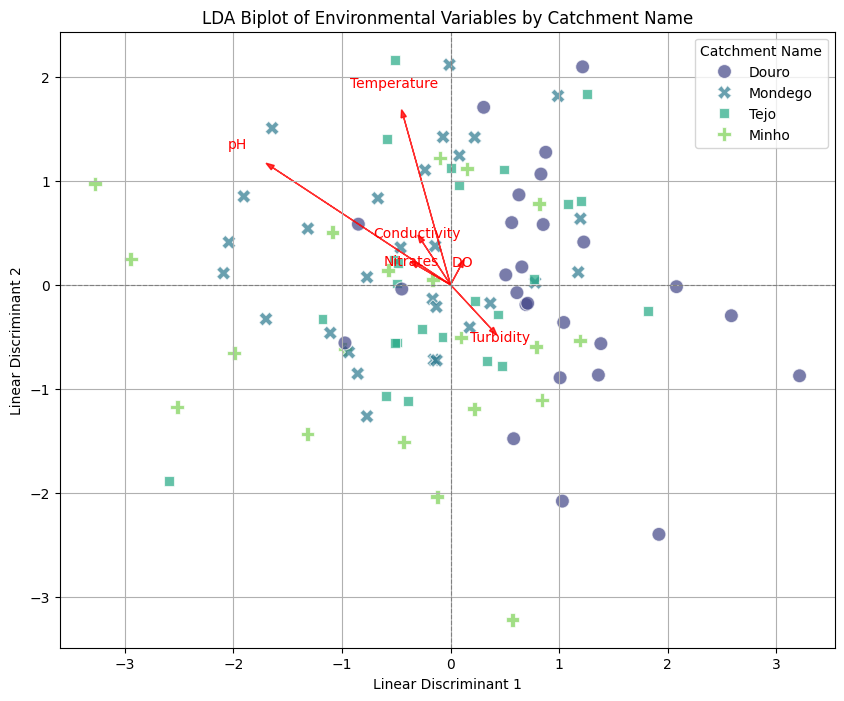

In [5]:
# prompt: 'Run a Linear Discriminant Analysis based on quantitative environmental variables', 'using the Douro, Tejo, Mondego and Minho basins as the pre-determined groups', and 'Produce a biplot with ‘Catchment_name’ as a grouping variable.'
# Note: Added conditional plotting for LDA biplot based on the number of available components and an alternative histogram plot if only one component is available.

# Perform LDA
# The number of components in LDA is at most n_classes - 1
lda = LinearDiscriminantAnalysis(n_components=len(y.unique()) - 1)
lda_components = lda.fit_transform(X_scaled, y)

# Create a DataFrame for LDA results
lda_df = pd.DataFrame(data=lda_components, columns=[f'LD{i+1}' for i in range(lda_components.shape[1])])
lda_df['Catchment_name'] = y.reset_index(drop=True)

# Plotting the LDA Biplot (only if at least 2 components are available)
if lda_components.shape[1] >= 2:
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x='LD1', y='LD2', hue='Catchment_name', data=lda_df,
        s=100, alpha=0.7, palette='viridis', style='Catchment_name'
    )

    # Add loadings (coefficients) to approximate a biplot for LDA
    # Note: LDA coefficients are not directly comparable to PCA loadings in the same way.
    # This is an approximation for visualization purposes.
    coeffs = lda.coef_.T
    # Normalize coefficients for better visualization scale
    for i, var in enumerate(X.columns):
        # Scale the coefficients for visibility on the plot
        # This scaling is heuristic and might need adjustment based on data
        scale_factor_ld1 = np.max(np.abs(lda_df['LD1'])) / np.max(np.abs(coeffs[:, 0])) if np.max(np.abs(coeffs[:, 0])) != 0 else 1
        scale_factor_ld2 = np.max(np.abs(lda_df['LD2'])) / np.max(np.abs(coeffs[:, 1])) if np.max(np.abs(coeffs[:, 1])) != 0 else 1

        plt.arrow(0, 0, coeffs[i, 0] * 0.5 * scale_factor_ld1, coeffs[i, 1] * 0.5 * scale_factor_ld2,
                  color='r', alpha=0.8, head_width=0.05)
        plt.text(coeffs[i, 0] * 0.6 * scale_factor_ld1, coeffs[i, 1] * 0.6 * scale_factor_ld2,
                 var, color='r', ha='center', va='center')

    plt.title('LDA Biplot of Environmental Variables by Catchment Name')
    plt.xlabel('Linear Discriminant 1')
    plt.ylabel('Linear Discriminant 2')
    plt.grid(True)
    plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
    plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
    plt.legend(title='Catchment Name')
    plt.show()
else:
    print("Not enough discriminant components (less than 2) to create a 2D biplot.")
    print(f"LDA components available: {lda_components.shape[1]}")
    plt.figure(figsize=(8, 6))
    sns.histplot(x='LD1', hue='Catchment_name', data=lda_df, kde=True, palette='viridis')
    plt.title('LDA: Distribution of Linear Discriminant 1 by Catchment Name')
    plt.xlabel('Linear Discriminant 1')
    plt.ylabel('Density')
    plt.legend(title='Catchment Name')
    plt.show()